# Information theory in practice

The three quantities that show up everywhere in modeling - entropy (uncertainty), KL divergence (the cost of using the wrong distribution), and mutual information (how much one variable tells you about another) - and a direct application: ranking features by mutual information for feature selection. These are the units behind log-likelihood, cross-entropy loss, and bits-per-character.


## Entropy, divergence, and information

Definition (entropy). The entropy of a discrete distribution $p$ is $H(p)=-\sum_x p(x)\log p(x)$, the
average surprise, measured in bits with $\log_2$. It is nonnegative, zero only for a point mass, and
maximized by the uniform distribution.

Definition (Kullback-Leibler divergence). $\mathrm{KL}(p\,\|\,q)=\sum_x p(x)\log\tfrac{p(x)}{q(x)}$, the
expected log-likelihood ratio, a directed measure of how $q$ fails to describe data from $p$.

Theorem (Gibbs' inequality). $\mathrm{KL}(p\,\|\,q)\ge 0$, with equality if and only if $p=q$.

Proof. Using $\log t \le t-1$ (concavity of $\log$),
$-\mathrm{KL}(p\|q)=\sum_x p(x)\log\tfrac{q(x)}{p(x)} \le \sum_x p(x)\big(\tfrac{q(x)}{p(x)}-1\big)
=\sum_x q(x)-\sum_x p(x)=0$, so $\mathrm{KL}\ge 0$. Equality in $\log t\le t-1$ holds only at $t=1$, i.e.
$p=q$ everywhere. $\quad\blacksquare$

Definition (mutual information). $I(X;Y)=\mathrm{KL}\big(p(x,y)\,\|\,p(x)p(y)\big)=H(X)-H(X\mid Y)$. By
Gibbs' inequality $I(X;Y)\ge 0$, with equality if and only if $X$ and $Y$ are independent. Mutual
information measures all dependence, not just linear association.

## Two theorems and a warning about correlation

Theorem (data processing inequality). If $X\to Y\to Z$ form a Markov chain (Z depends on X only through
Y), then $I(X;Z)\le I(X;Y)$: processing cannot create information about $X$.

Proof. By the chain rule $I(X;Y,Z)=I(X;Y)+I(X;Z\mid Y)=I(X;Z)+I(X;Y\mid Z)$. The Markov property makes
$I(X;Z\mid Y)=0$, and $I(X;Y\mid Z)\ge 0$, so $I(X;Y)=I(X;Z)+I(X;Y\mid Z)\ge I(X;Z)$. $\quad\blacksquare$

Theorem (source coding, Shannon). The entropy $H(p)$ is the minimum expected number of bits per symbol to
losslessly encode an iid source with distribution $p$; no code does better, and codes approaching $H$
exist. This is why entropy is the natural unit of information and why cross-entropy is the right training
loss for probabilistic models.

Counterexample (zero correlation is not independence). Correlation measures only linear association.
Let $X\sim\mathcal N(0,1)$ and $Y=X^2$. Then $\mathrm{Cov}(X,Y)=\mathbb E[X^3]=0$, so $X$ and $Y$ are
uncorrelated, yet $Y$ is a deterministic function of $X$, so $I(X;Y)>0$ and they are maximally dependent.
Mutual information detects this nonlinear dependence that correlation is blind to; this is exactly why
the feature-selection section uses MI. We confirm both Gibbs' inequality and this counterexample below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
rng = np.random.RandomState(0)
def entropy(p):
    p = np.asarray(p, float); p = p[p > 0]; return -np.sum(p * np.log2(p))
def kl(p, q):
    p, q = np.asarray(p, float), np.asarray(q, float); m = p > 0; return np.sum(p[m] * np.log2(p[m] / q[m]))

## 1. Entropy: how many bits of surprise

The entropy $H(X)=-\sum_x p(x)\log_2 p(x)$ is the average number of bits needed to encode a draw - maximal for a uniform distribution, zero for a certain one. It quantifies uncertainty. We trace the entropy of a coin from fair (1 bit) to certain (0 bits).


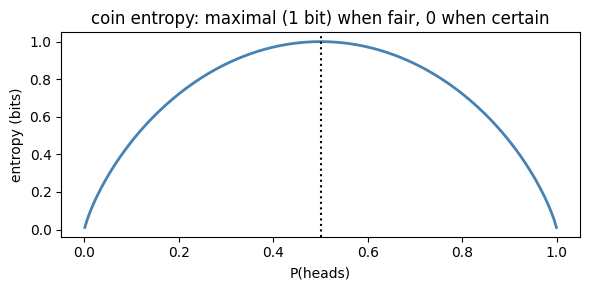

H(fair coin)=1.00 bit ; H(0.9 coin)=0.47 bit


In [2]:
ps = np.linspace(0.001, 0.999, 200)
H = [entropy([p, 1 - p]) for p in ps]
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ps, H, color='steelblue', lw=2)
ax.axvline(0.5, color='k', ls=':'); ax.set_xlabel('P(heads)'); ax.set_ylabel('entropy (bits)')
ax.set_title('coin entropy: maximal (1 bit) when fair, 0 when certain')
plt.tight_layout(); plt.show()
print('H(fair coin)=%.2f bit ; H(0.9 coin)=%.2f bit' % (entropy([0.5, 0.5]), entropy([0.9, 0.1])))

## 2. KL divergence: the cost of the wrong distribution

$D_{\mathrm{KL}}(p\Vert q)=\sum_x p(x)\log_2\frac{p(x)}{q(x)}$ is the extra bits you pay encoding data from $p$ with a code built for $q$ - it is $\ge 0$, zero only when $p=q$, and asymmetric ($D(p\Vert q)\ne D(q\Vert p)$). Minimizing KL to the data is exactly what maximum likelihood does. We show the asymmetry, which is why "VI minimizes $D(q\Vert p)$" (mode-seeking) behaves differently from $D(p\Vert q)$ (mean-seeking).


In [3]:
p = np.array([0.7, 0.2, 0.1]); q = np.array([0.4, 0.4, 0.2])
print('D(p||q) = %.3f bits   D(q||p) = %.3f bits   (asymmetric)' % (kl(p, q), kl(q, p)))
print('D(p||p) = %.3f bits   (zero only when identical)' % kl(p, p))

D(p||q) = 0.265 bits   D(q||p) = 0.277 bits   (asymmetric)
D(p||p) = 0.000 bits   (zero only when identical)


## 3. Mutual information for feature selection

Mutual information $I(X;Y)=H(Y)-H(Y\mid X)$ measures how many bits knowing $X$ saves about $Y$ - zero iff they are independent, and unlike correlation it catches nonlinear dependence. For supervised learning it is the natural feature-relevance score: rank candidate features by their MI with the label. We build a dataset with a few informative features buried among noise, and show MI surfaces exactly the informative ones (including a nonlinear one that correlation misses).


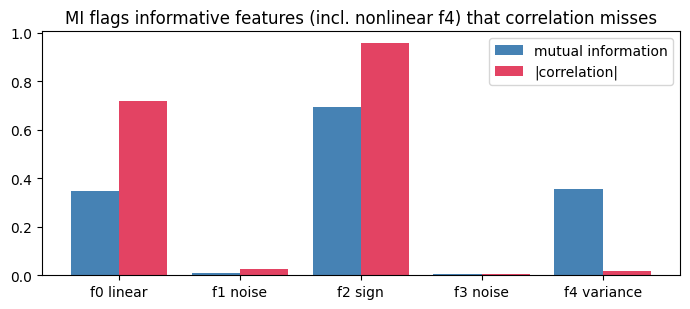

MI ranks features: ['f2 sign', 'f4 variance', 'f0 linear', 'f1 noise', 'f3 noise']


In [4]:
from sklearn.feature_selection import mutual_info_classif
n = 2000
y = rng.randint(0, 2, n)
X = np.column_stack([
    y + rng.normal(0, 0.5, n),            # f0: linearly informative
    rng.normal(0, 1, n),                  # f1: pure noise
    (y * 2 - 1) * rng.normal(1, 0.3, n),  # f2: informative via sign/scale
    rng.normal(0, 1, n),                  # f3: pure noise
    np.where(y == 1, rng.normal(0, 0.3, n), rng.normal(0, 2, n)),  # f4: informative via VARIANCE (nonlinear)
])
mi = mutual_info_classif(X, y, random_state=0)
corr = np.array([abs(np.corrcoef(X[:, j], y)[0, 1]) for j in range(X.shape[1])])
labels = ['f0 linear', 'f1 noise', 'f2 sign', 'f3 noise', 'f4 variance']

fig, ax = plt.subplots(figsize=(7, 3.2))
xs = np.arange(len(labels)); w = 0.4
ax.bar(xs - w/2, mi, w, color='steelblue', label='mutual information')
ax.bar(xs + w/2, corr, w, color='crimson', alpha=0.8, label='|correlation|')
ax.set_xticks(xs); ax.set_xticklabels(labels); ax.legend()
ax.set_title('MI flags informative features (incl. nonlinear f4) that correlation misses')
plt.tight_layout(); plt.show()
print('MI ranks features:', [labels[j] for j in np.argsort(-mi)])

f4 is informative only through its variance (same mean in both classes), so its linear correlation with the label is near zero - yet mutual information flags it clearly. That is the practical reason to reach for MI over correlation when screening features for nonlinear models.


## Test mutual information against a permutation null

Estimated mutual information is positively biased in finite samples - a pure-noise feature shows MI $> 0$ just from sampling. So a raw MI ranking can promote noise. The fix is a permutation null: shuffle the label many times, recompute MI, and keep only features whose real MI exceeds the null band (a nonparametric significance test). We apply it to the mix of informative and noise features.


In [5]:
def mi_perm_test(X, y, n_perm=200, seed=0):
    r = np.random.RandomState(seed)
    obs = mutual_info_classif(X, y, random_state=0)
    null = np.array([mutual_info_classif(X, r.permutation(y), random_state=0) for _ in range(n_perm)])
    p = (1 + (null >= obs).sum(0)) / (1 + n_perm)         # one-sided permutation p-value
    return obs, null.mean(0), p
obs, null_mean, pval = mi_perm_test(X, y)
print(' feat   observed MI   null-mean MI   p-value   significant?')
for j in range(X.shape[1]):
    print('  f%d      %.3f         %.3f        %.3f      %s' %
          (j, obs[j], null_mean[j], pval[j], 'YES' if pval[j] < 0.05 else 'no (noise)'))
print('the noise features have nonzero estimated MI but fall inside the null -> correctly rejected.')

 feat   observed MI   null-mean MI   p-value   significant?
  f0      0.349         0.005        0.005      YES
  f1      0.008         0.005        0.244      no (noise)
  f2      0.693         0.004        0.005      YES
  f3      0.003         0.005        0.423      no (noise)
  f4      0.354         0.004        0.005      YES
the noise features have nonzero estimated MI but fall inside the null -> correctly rejected.


## Illustration: Gibbs' inequality and dependence without correlation

We confirm that the KL divergence is nonnegative and vanishes only when the distributions agree, then
exhibit a pair of variables with zero correlation but clearly nonzero mutual information, the signature
case where correlation misleads and information does not.

In [6]:
from sklearn.feature_selection import mutual_info_regression
rng = np.random.RandomState(0)
def kl(p, q): return np.sum(p * np.log(p / q))
p = np.array([0.1, 0.2, 0.3, 0.4]); q = np.array([0.25, 0.25, 0.25, 0.25])
print('KL(p || q) = %.4f >= 0' % kl(p, q))
print('KL(p || p) = %.4f (zero only when the distributions are identical)' % kl(p, p))
x = rng.normal(0, 1, 5000); y = x ** 2                   # exact dependence, zero correlation
print('correlation(X, X^2)      = %.3f  (essentially zero: no linear association)' % np.corrcoef(x, y)[0, 1])
print('mutual information(X, X^2) = %.3f nats  (clearly positive: MI sees the nonlinear dependence)' %
      mutual_info_regression(x.reshape(-1, 1), y, random_state=0)[0])

KL(p || q) = 0.1064 >= 0
KL(p || p) = 0.0000 (zero only when the distributions are identical)
correlation(X, X^2)      = -0.003  (essentially zero: no linear association)
mutual information(X, X^2) = 5.919 nats  (clearly positive: MI sees the nonlinear dependence)


## References

- Shannon, C. E. (1948). A mathematical theory of communication (https://doi.org/10.1002/j.1538-7305.1948.tb01338.x). Bell System Tech. J. 27, 379-423, 623-656.
- Cover, T. M. & Thomas, J. A. (2006). Elements of Information Theory, 2nd ed. Wiley.
- MacKay, D. J. C. (2003). Information Theory, Inference, and Learning Algorithms (https://www.inference.org.uk/itila/). Cambridge University Press.
- Kraskov, A., Stögbauer, H. & Grassberger, P. (2004). Estimating mutual information (https://doi.org/10.1103/PhysRevE.69.066138). Phys. Rev. E 69, 066138. - the KSG $k$-NN estimator.
- Peng, H., Long, F. & Ding, C. (2005). Feature selection based on mutual information: mRMR (https://doi.org/10.1109/TPAMI.2005.159). IEEE TPAMI 27(8), 1226-1238.


## Exercises and extensions

1. MI estimation is hard. For continuous variables compare histogram-binning MI (sensitive to bin width) against the Kraskov-Stögbauer-Grassberger $k$-NN estimator on data with known MI; quantify bias and variance vs sample size and dimension. Reproduce the binning estimator's positive bias.
2. mRMR feature selection. Implement minimum-redundancy maximum-relevance selection (Peng et al.): greedily pick features maximizing MI with the label minus average MI with already-selected features. Compare to plain max-relevance on a dataset with redundant informative features, and show mRMR avoids picking near-duplicates.
3. Cross-entropy = entropy + KL. For a fitted language/character model, decompose the held-out cross-entropy into the data entropy plus the KL divergence model‖truth (the model's excess bits), and relate to bits/character (character_models_chow_liu).
4. Information gain and the bottleneck. Show a decision-tree split's information gain equals the mutual information between split and label; then implement a toy information-bottleneck compression and discuss the relevance-compression trade-off (Cover & Thomas; MacKay).
